Progetto Data Analytics, attività 1.

Svolto da: Ugo Valitutto, Matteo Lombardi, Martina Petrillo.

Il progetto si suddivide nelle seguenti parti:

* Introduzione e descrizione generale del Dataset;
* Pulizia del Dataset;
* Analisi Esplorativa;
* Outlier Detection;
* Predizione degli streams fatti su Spotify nei primi mesi del 2024;
* Conclusione.

# **Introduzione**

Il dataset utilizzato per la nostra analisi è Most_Streamed_Spotify_Songs_2024, disponibile su kaggle al link https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024.

Il dataset presenta 4600 righe e 29 colonne. Ogni riga rappresenta una canzone. Le colonne contengono il nome della traccia, dell'album e dell'artista; la data di rilascio della canzone, un punteggio valutato sulla base di alcuni parametri (non esplicitati nella descrizione del dataset), con una relativa classifica, ed infine diversi dati relativi a varie piattaforme di streaming per musica e altri siti web. In particolare abbiamo deciso di concentrarci su:
* Track: titolo della canzone;
* Album Name: titolo dell'album;
* Artist: nome dell'artista;
* Release Date: data di rilascio della canzone;
* Track Score: punteggio assegnato alla canzone;
* Explicit Track: presenza di contenuto esplicito;
* Spotify Streams: numero totale ascolti su spotify;
* Spotify Playlist Count: numero di playlist in cui è contenuta la canzone;
* Spotify Playlist Reach: numero totale di utenti che seguono una playlist spotify in cui è presente la canzone;
* Spotify Popularity: punteggio assegnato in base alla popolarità su spotify;
* YouTube Views: numero di visualizzazioni su Youtube;
* YouTube Likes: numero di like su YouTube;
* YouTube Playlist Reach: numero totale di utenti che seguono una playlist YouTube in cui è presente la canzone;
* TikTok Posts: numero di post pubblicati su TikTok contenenti la canzone;
* TikTok Likes: numero di like di ogni post contentente la canzone;
* TikTok Views: numero di visualizzazioni dei post contenente la canzone.


Carichiamo il dataset presente sul nostro drive google.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Big_Data_Analytics/Progetto_Data_Analytics')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Della data di rilascio della canzone consideriamo l'anno ed il mese in due colonne separate.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('Most_Streamed_Spotify_Songs_2024.csv',encoding='latin-1')
df['Release Date'] = pd.to_datetime(df['Release Date'])
df['Release Year'] = df['Release Date'].dt.year
df['Release Month'] = df['Release Date'].dt.month
df=df[['Track','Album Name','Artist','Release Year','Release Month','Track Score','Explicit Track', 'Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach',
       'Spotify Popularity', 'YouTube Views','YouTube Likes','YouTube Playlist Reach','TikTok Posts','TikTok Likes','TikTok Views']]
df

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024,4,725.4,0,"390,470,936","30,716","196,631,588",92.0,"84,274,754","1,713,126","150,597,040","5,767,700","651,565,900","5,332,281,936"
1,Not Like Us,Not Like Us,Kendrick Lamar,2024,5,545.9,1,"323,703,884","28,113","174,597,137",92.0,"116,347,040","3,486,739","156,380,351","674,700","35,223,547","208,339,025"
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024,3,538.4,0,"601,309,283","54,331","211,607,669",92.0,"122,599,116","2,228,730","373,784,955","3,025,400","275,154,237","3,369,120,610"
3,Flowers,Flowers - Single,Miley Cyrus,2023,1,444.9,0,"2,031,280,633","269,802","136,569,078",85.0,"1,096,100,899","10,629,796","3,351,188,582","7,189,811","1,078,757,968","14,603,725,994"
4,Houdini,Houdini,Eminem,2024,5,423.3,1,"107,034,922","7,223","151,469,874",88.0,"77,373,957","3,670,188","112,763,851","16,400",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,2017,9,19.4,1,"305,049,963","65,770","5,103,054",71.0,"149,247,747","1,397,590","53,016","48,370","20,202,000","143,934,379"
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"")",Atif Aslam,2018,7,19.4,0,"52,282,360","4,602","1,449,767",56.0,"943,920,245","5,347,766","24,973,048",NaN,"1,721","19,935"
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2020,2,19.4,1,"189,972,685","72,066","6,704,802",65.0,"201,027,333","1,081,402","29,253,152","7,596","5,288,677","36,849,005"
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,2016,11,19.4,0,"145,467,020","14,037","7,387,064",66.0,"1,118,595,159","3,868,828","25,150,516","11,433","2,534,831","37,757,301"


Abbiamo un totale di 4600 righe e 17 colonne.  Visualizziamo il tipo di dati per ogni colonna.

In [ ]:
df.dtypes

,0
Track,object
Album Name,object
Artist,object
Release Year,int32
Release Month,int32
Track Score,float64
Explicit Track,int64
Spotify Streams,object
Spotify Playlist Count,object
Spotify Playlist Reach,object


Trasformiamo le colonne di tipo object che contengono dati numerici, scritti sottoforma di stringa, nel formato opportuno.

In [ ]:
columns_to_convert = ['Spotify Streams','Spotify Playlist Count',
                      'Spotify Playlist Reach','YouTube Views','YouTube Likes', 'TikTok Posts',
                      'TikTok Likes','TikTok Views','YouTube Playlist Reach']
for col in columns_to_convert:
  df[col] = df[col].str.replace(',', '').astype(float)
print(df.dtypes)
df.head()


Track                      object
Album Name                 object
Artist                     object
Release Year                int32
Release Month               int32
Track Score               float64
Explicit Track              int64
Spotify Streams           float64
Spotify Playlist Count    float64
Spotify Playlist Reach    float64
Spotify Popularity        float64
YouTube Views             float64
YouTube Likes             float64
YouTube Playlist Reach    float64
TikTok Posts              float64
TikTok Likes              float64
TikTok Views              float64
dtype: object


,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024,4,725.4,0,3.904709e+08,30716.0,196631588.0,92.0,8.427475e+07,1713126.0,1.505970e+08,5767700.0,6.515659e+08,5.332282e+09
1,Not Like Us,Not Like Us,Kendrick Lamar,2024,5,545.9,1,3.237039e+08,28113.0,174597137.0,92.0,1.163470e+08,3486739.0,1.563804e+08,674700.0,3.522355e+07,2.083390e+08
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024,3,538.4,0,6.013093e+08,54331.0,211607669.0,92.0,1.225991e+08,2228730.0,3.737850e+08,3025400.0,2.751542e+08,3.369121e+09
3,Flowers,Flowers - Single,Miley Cyrus,2023,1,444.9,0,2.031281e+09,269802.0,136569078.0,85.0,1.096101e+09,10629796.0,3.351189e+09,7189811.0,1.078758e+09,1.460373e+10
4,Houdini,Houdini,Eminem,2024,5,423.3,1,1.070349e+08,7223.0,151469874.0,88.0,7.737396e+07,3670188.0,1.127639e+08,16400.0,NaN,NaN


Infine, stampiamo le statistiche di base del nostro Dataset.

In [ ]:
df.describe()

,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
count,4600.000000,4600.000000,4600.000000,4600.000000,4.487000e+03,4530.000000,4.528000e+03,3796.000000,4.292000e+03,4.285000e+03,3.591000e+03,3.427000e+03,3.620000e+03,3.619000e+03
mean,2020.616739,6.046304,41.844043,0.358913,4.473873e+08,59390.829801,2.334682e+07,63.501581,4.027967e+08,2.930049e+06,3.439601e+08,9.443076e+05,1.126375e+08,1.161158e+09
std,3.611707,3.419663,38.543766,0.479734,5.384439e+08,71131.406625,2.968717e+07,16.186438,7.019000e+08,4.593640e+06,6.704811e+08,2.442080e+06,5.498123e+08,5.881584e+09
min,1987.000000,1.000000,19.400000,0.000000,1.071000e+03,1.000000,1.000000e+00,1.000000,9.130000e+02,2.500000e+01,1.000000e+00,1.000000e+00,3.000000e+00,1.900000e+01
25%,2019.000000,3.000000,23.300000,0.000000,7.038630e+07,6718.000000,4.791612e+06,61.000000,4.073032e+07,4.095490e+05,1.171869e+07,3.818650e+04,5.814876e+06,5.902786e+07
50%,2022.000000,6.000000,29.900000,0.000000,2.398507e+08,32312.500000,1.325948e+07,67.000000,1.482696e+08,1.257935e+06,9.814272e+07,1.822000e+05,2.653441e+07,2.659172e+08
75%,2023.000000,9.000000,44.425000,1.000000,6.283638e+08,86038.750000,2.966069e+07,73.000000,4.647882e+08,3.573193e+06,3.114059e+08,7.948775e+05,9.328418e+07,9.134169e+08
max,2024.000000,12.000000,725.400000,1.000000,4.281469e+09,590392.000000,2.623434e+08,96.000000,1.632276e+10,6.231118e+07,7.289707e+09,4.290000e+07,2.347422e+10,2.332323e+11


# **Pulizia del dataset**

Innanzitutto verifichiamo se ci sono dei duplicati all'interno del dataset e in caso affermativo li andiamo ad eliminare.

In [ ]:
Duplicati=df[df.duplicated(keep=False)]
Duplicati

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
2449,Tennessee Orange,Tennessee Orange,Megan Moroney,2022,9,28.9,0,227893586.0,28139.0,12480714.0,73.0,30913276.0,159791.0,238206228.0,77661.0,13324305.0,117505652.0
2450,Tennessee Orange,Tennessee Orange,Megan Moroney,2022,9,28.9,0,227893586.0,28139.0,12480714.0,73.0,30913276.0,159791.0,238206228.0,77661.0,13324305.0,117505652.0
3447,Dembow,Dembow,Danny Ocean,2017,12,23.3,0,579189526.0,60397.0,11805084.0,65.0,828853696.0,3086157.0,199705679.0,84450.0,21202350.0,158504854.0
3450,Dembow,Dembow,Danny Ocean,2017,12,23.3,0,579189526.0,60397.0,11805084.0,65.0,828853696.0,3086157.0,199705679.0,84450.0,21202350.0,158504854.0


In [ ]:
df.drop_duplicates(inplace=True)

Verifichiamo che effettivamente i due duplicati sono stati rimossi.

In [ ]:
df.shape

(4598, 17)

Vediamo quanti NaN sono presenti all'interno del dataset.

In [ ]:
df.isna().sum()

,0
Track,0
Album Name,0
Artist,5
Release Year,0
Release Month,0
Track Score,0
Explicit Track,0
Spotify Streams,113
Spotify Playlist Count,70
Spotify Playlist Reach,72


Ci sono 5 canzoni di cui manca il nome dell'artista. Ai fini della predizione degli Spotify Streams, conoscere il nome dell'artista non è rilevante. Basterebbe fare una semplice ricerca su internet per risalire all'artista sulla base del nome della canzone e dell'album. Stampiamo queste righe per verificare che non siano presenti altri NaN.

In [ ]:
nan_rows=df.loc[df['Artist'].isnull()]
nan_rows

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
311,Cool,JnD Mix,NaN,2024,5,86.5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
480,I Wanna Party,I Wanna Party - Single,NaN,2024,5,70.3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1345,Marlboro Remix,Marlboro Remix - Single,NaN,2024,6,40.6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1561,Melting,Melting - Single,NaN,2024,6,37.2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3402,La ï¿½ï¿½ltima Vez (Yo Te Per,La ï¿½ï¿½ltima Vez (Yo Te Perdï¿½ï¿½),NaN,2024,5,23.6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


È possibile osservare che queste righe presentano NaN in tutte le colonne di nostro interesse e quindi conviene eliminarle.

In [ ]:
df_drop=df.dropna(subset=['Artist'])
df_drop.isna().sum()

,0
Track,0
Album Name,0
Artist,0
Release Year,0
Release Month,0
Track Score,0
Explicit Track,0
Spotify Streams,108
Spotify Playlist Count,65
Spotify Playlist Reach,67


Osserviamo che la colonna TikTok Posts presenta 1168 NaN. Essendo un valore così elevato, potrebbe non essere ragionevole andare ad imputare questi valori. Valutiamo cosa fare anche in base all'eventuale presenza di altri NaN all'interno delle stesse righe.

In [ ]:
df_drop[df_drop['TikTok Posts'].isna()]

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
6,Beautiful Things,Beautiful Things,Benson Boone,2024,1,407.2,0,9.001588e+08,73118.0,201585714.0,86.0,3.087231e+08,4120760.0,4.601580e+09,NaN,29584940.0,534915313.0
8,Danza Kuduro - Cover,ýýýýýýýýýýýýýýýýýýýýý - ýýýýýýýýýýýýýýýýýý -,MUSIC LAB JPN,2024,6,355.7,1,1.653018e+09,1.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,I Had Some Help (feat. Morgan Wallen),I Had Some Help,Post Malone,2024,5,322.1,1,2.500804e+08,16219.0,168766158.0,91.0,3.222906e+07,550191.0,3.271308e+08,NaN,184500.0,2100000.0
11,The Door,The Door,Teddy Swims,2024,6,320.2,1,1.111551e+08,2.0,263767.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,Like That,WE DON'T TRUST YOU,Future,2024,3,308.2,1,3.551864e+08,43025.0,108168634.0,88.0,9.808149e+07,1456177.0,1.744914e+08,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,Bodak Yellow,Pï¿½ï¿½bu (Camemicua,Serranow,2017,11,19.5,0,8.402000e+03,4.0,33.0,NaN,1.152051e+09,8477904.0,2.939119e+08,NaN,NaN,NaN
4588,Braten,Braten,Steps,2022,12,19.5,1,2.422310e+05,390.0,6228.0,25.0,2.404915e+08,1805305.0,1.666826e+08,NaN,NaN,NaN
4593,"Jaragandi (From ""Game Changer"") (Telugu)","Jaragandi (From ""Game Changer"") (Telugu)",Thaman S,2024,3,19.4,0,3.754914e+06,101.0,1306604.0,NaN,3.431531e+07,431343.0,NaN,NaN,NaN,NaN
4594,ýýýýýýýýýýýý (ýýýýýýýýýýýýýý ýýýýýýýýýýýý) [pr...,ýýýýýýýýýýýý (ýýýýýýýýýýýýýý ýýýýýýýýýýýý) [pr...,BUSHIDO ZHO,2024,5,19.4,1,5.092789e+06,685.0,185936.0,62.0,1.042300e+07,288976.0,NaN,NaN,3635.0,27800.0


Dal momento che anche in altre colonne sono presenti dei NaN, decidiamo di rimuovere le righe con dati mancanti nella colonna TikTok Posts.

In [ ]:
df_drop=df_drop.dropna(subset=['TikTok Posts'])
df_drop.isna().sum()

,0
Track,0
Album Name,0
Artist,0
Release Year,0
Release Month,0
Track Score,0
Explicit Track,0
Spotify Streams,21
Spotify Playlist Count,3
Spotify Playlist Reach,3


Possiamo notare che, avendo rimosso le righe contenenti valori mancanti nella colonna TikTok Posts, il numero di NaN è diminuito per la maggior parte delle variabili. Ora confrontiamo la distribuzione di ogni variabile prima e dopo il drop dei NaN.



In 'plt.hist' impostiamo il parametro 'density=True' che normalizza l'istogramma in modo tale che l'area totale delle barre sia uguale a 1. Ciò vuol dire che l'altezza di ciascuna barra rappresenta la densità di probabilità dei dati all'interno della barra corrispondente, piuttosto che il conteggio Anche per la variabile Release Month visualizziamo la frequenza relativa nel bar-plot. Questo è utile per confrontare distribuzioni di dati con diversi numeri di osservazioni. Infatti, nel nostro caso, vogliamo confrontare le distribuzioni di ogni colonna prima e dopo aver rimosso delle righe.

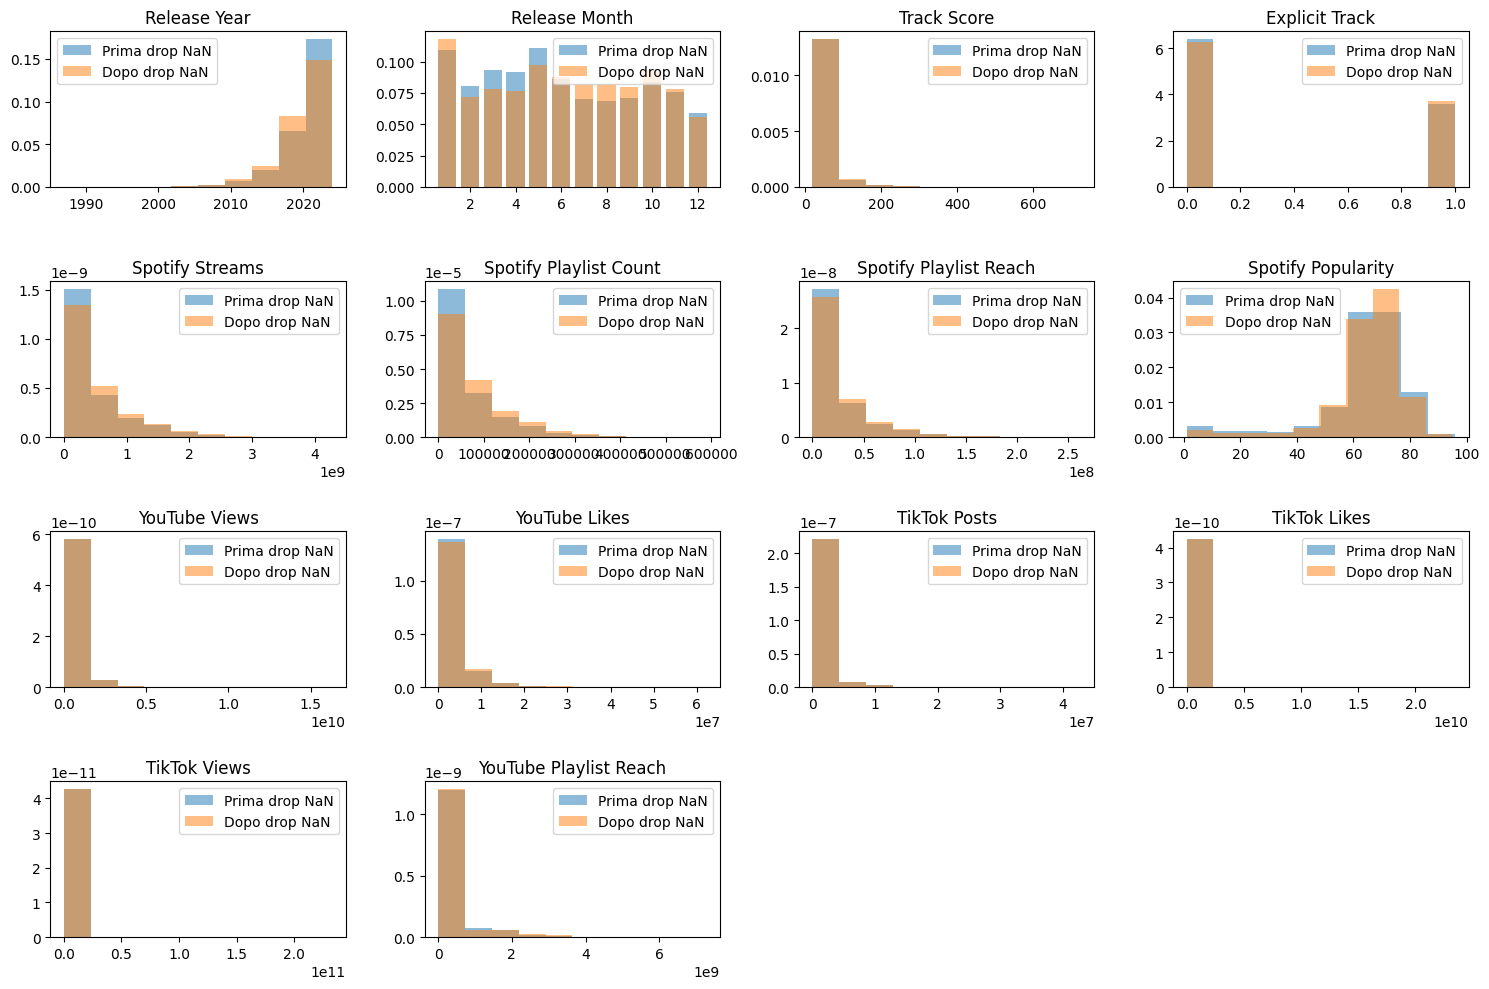

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

plt.figure(figsize=(15, 10))
columns=['Release Year','Release Month','Track Score','Explicit Track', 'Spotify Streams','Spotify Playlist Count',
                      'Spotify Playlist Reach','Spotify Popularity', 'YouTube Views','YouTube Likes', 'TikTok Posts',
                      'TikTok Likes','TikTok Views','YouTube Playlist Reach']
i=0
for col in columns:
  i=i+1
  plt.subplot(4,4,int(i))
  if col == 'Release Month':
    conteggi = Counter(df['Release Month'])
    categorie = list(conteggi.keys())
    valori_conteggi = list(conteggi.values())
    frequenze_relative = np.array(valori_conteggi) / np.sum(valori_conteggi)
    plt.bar(categorie, frequenze_relative, alpha=0.5, label='Prima drop NaN')

    conteggi = Counter(df_drop['Release Month'])
    categorie = list(conteggi.keys())
    valori_conteggi = list(conteggi.values())
    frequenze_relative = np.array(valori_conteggi) / np.sum(valori_conteggi)
    plt.bar(categorie, frequenze_relative, alpha=0.5, label='Dopo drop NaN')
  else:
    plt.hist(df[col], alpha=0.5, label='Prima drop NaN', density=True)
    plt.hist(df_drop[col], alpha=0.5, label='Dopo drop NaN', density=True)
  plt.title(col)
  plt.legend()

plt.tight_layout()
plt.show()

In base agli istogrammi ottenuti, notiamo che la distribuzione dei nostri dati non subisce notevoli cambiamenti prima e dopo il drop dei NaN.

Abbiamo deciso di imputare i restanti valori NaN tramite il metodo KNN Imputer. Prima di dare il nostro dataset in input ad un algoritmo di machine learning, è ragionevole normalizzare i dati. Riscaliamo i dati tramite il Robust Scaler, che è in grado di gestire variabili non distribuite in modo simmetrico ed è molto robusto agli outlier.

PRIMA DI IMPUTARE CON KNN, RIMUOVO ANCHE TUTTI I NAN DELLA COLONNA SPOTIFY STREAMS E FACCIO KNN NON CONSIDERANDOLA. SPOTIFY STREAMS È LA COLONNA SU CUI SI VUOLE FARE PREDIZIONE, QUINDI NON HA SENSO IMPUTARE SULLA BASE DI SPOTIFY STREAMS I NAN DELLE ALTRE COLONNE CHE POI VERRANO UTILIZZATI PER PREDIIRE SPOTIFY STREAMS.

In [ ]:
df_drop=df_drop.dropna(subset=['Spotify Streams'])
df_drop.isna().sum()

,0
Track,0
Album Name,0
Artist,0
Release Year,0
Release Month,0
Track Score,0
Explicit Track,0
Spotify Streams,0
Spotify Playlist Count,0
Spotify Playlist Reach,0


In [ ]:
from scipy.stats import boxcox
no_transf=['Release Year', 'Explicit Track']
to_log=['Spotify Playlist Count', 'Spotify Playlist Reach', 'YouTube Likes', 'YouTube Playlist Reach']
to_box_cox=['Spotify Popularity', 'YouTube Views', 'TikTok Posts', 'TikTok Likes', 'TikTok Views']


for var in to_log:
  df_drop.loc[:,var]=np.log(df_drop[var] + 1e-6)

lambda_dict = {}
for var in to_box_cox:
  non_nan_data = df_drop[var][~np.isnan(df_drop[var])]

  # Apply the Box-Cox transformation to the non-NaN elements
  transformed_data, lambda_value = boxcox(non_nan_data + 1e-6)
  lambda_dict[f'lambda_{var}'] = lambda_value

  # Create a copy of the original data array to preserve NaN positions
  result = np.empty_like(df_drop[var])
  result[:] = np.nan  # Initialize with NaNs

  # Place the transformed data back into their original positions
  df_drop.loc[~np.isnan(df_drop[var]), var] = transformed_data





In [ ]:
from sklearn.preprocessing import RobustScaler
columns_to_impute = ['Spotify Playlist Count','Spotify Playlist Reach','Spotify Popularity', 'YouTube Views','YouTube Likes','YouTube Playlist Reach',
         'TikTok Posts','TikTok Likes','TikTok Views']
scaler = RobustScaler()
df_drop[columns_to_impute] = scaler.fit_transform(df_drop[columns_to_impute])
df_drop.head()

<ipython-input-131-9ff8bdccdfc8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop[columns_to_impute] = scaler.fit_transform(df_drop[columns_to_impute])


,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024,4,725.4,0,3.904709e+08,-0.352233,1.620608,3.007157,-0.338002,0.023386,0.143152,1.400911,1.516906,1.385556
1,Not Like Us,Not Like Us,Kendrick Lamar,2024,5,545.9,1,3.237039e+08,-0.406949,1.543619,3.007157,-0.203019,0.397995,0.154547,0.467965,0.058026,-0.136602
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024,3,538.4,0,6.013093e+08,0.000165,1.668157,3.007157,-0.180438,0.162082,0.418041,1.096021,1.020506,1.127948
3,Flowers,Flowers - Single,Miley Cyrus,2023,1,444.9,0,2.031281e+09,0.990415,1.384491,2.015762,0.958641,0.985594,1.081285,1.510297,1.837084,2.009407
4,Houdini,Houdini,Eminem,2024,5,423.3,1,1.070349e+08,-1.246658,1.451573,2.425745,-0.372595,0.425025,0.055669,-0.694892,NaN,NaN


In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_drop[columns_to_impute]), columns=columns_to_impute)


Analogamente a quanto fatto prima, confrontiamo la distribuzione di ogni variabile prima e dopo aver imputato i NaN.

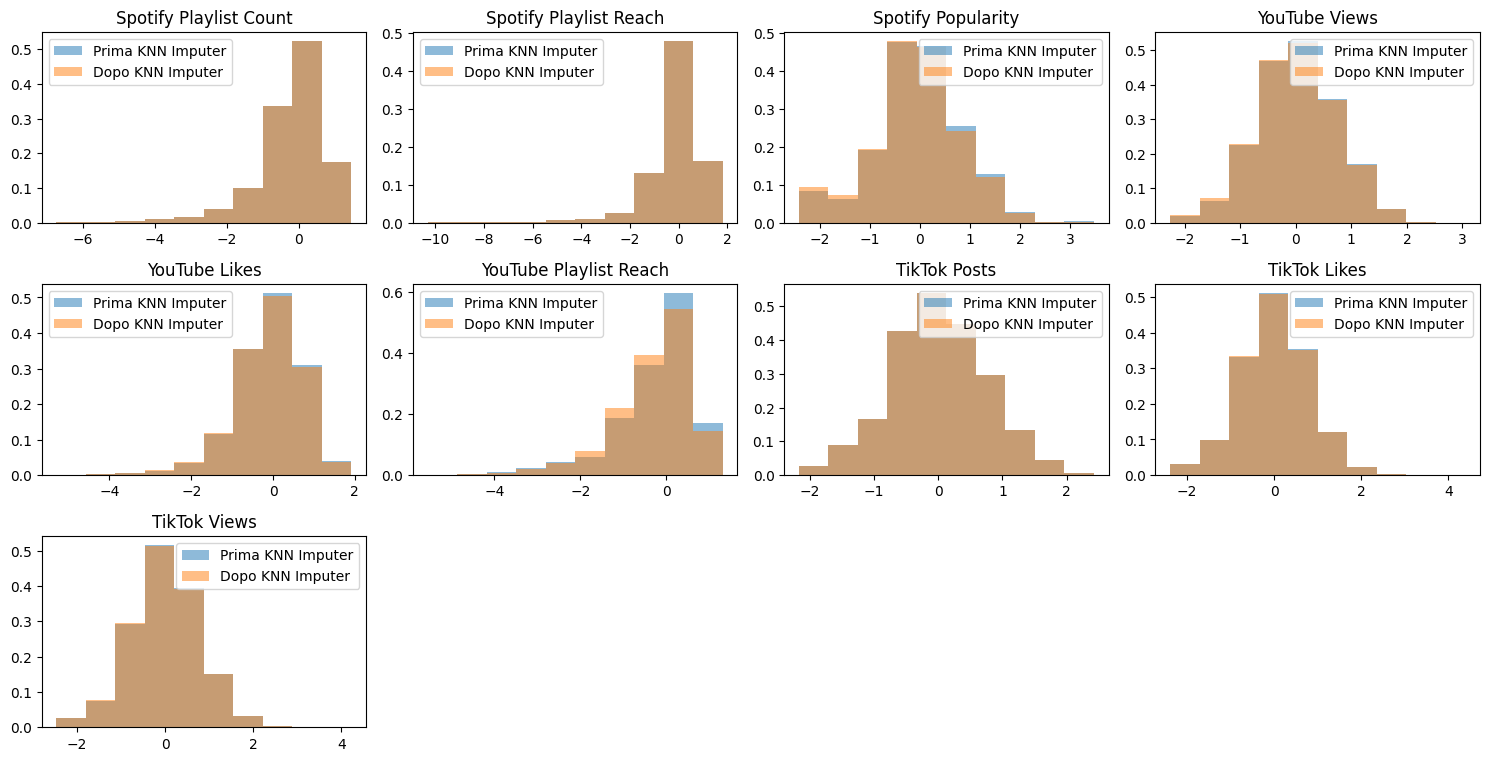

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
i=0

for col in columns_to_impute:
   i=i+1
   plt.subplot(4,4,int(i))
   plt.hist(df_drop[col],alpha=0.5, label='Prima KNN Imputer', density=True)
   plt.hist(df_knn_imputed[col],alpha=0.5, label='Dopo KNN Imputer', density=True)
   plt.title(str(col))
   plt.legend()
plt.tight_layout()
plt.show()

Osservando la distribuzione di ogni variabile numerica, prima e dopo l'imputazione, possiamo dire che le distribuzioni sono molto simili, fatta eccezione per la distribuzione della variabile 'Spotify Popularity' che presenta leggere differenze.

I risultati ottenuti possono essere considerati soddisfacenti e pertanto decidiamo di mantenere i valori appena imputati tramite KNN.

Invertiamo la normalizzazione tramite Robust Scaler E LE TRASFORMAZIONI LOGARITMO E BOX-COX per continuare a lavorare con i dati in scala originale.

In [ ]:
df_knn_imputed[columns_to_impute] = scaler.inverse_transform(df_knn_imputed[columns_to_impute])

for var in to_log:
  df_knn_imputed.loc[:,var]=np.exp(df_knn_imputed[var])

from scipy.special import inv_boxcox
for var in to_box_cox:
  df_knn_imputed.loc[:,var]=inv_boxcox(df_knn_imputed[var], lambda_dict[f'lambda_{var}'])


Ricostruiamo il dataset inserendo le colonne numeriche appena imputate tramite KNN.

In [ ]:
DataSet=pd.concat([df_drop[['Track','Album Name','Artist','Release Year','Release Month','Track Score','Explicit Track', 'Spotify Streams']].reset_index(drop=True),df_knn_imputed],axis=1)
DataSet.head()

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024,4,725.4,0,3.904709e+08,30716.000001,1.966316e+08,92.000001,8.427475e+07,1.713126e+06,1.505970e+08,5.767700e+06,6.515659e+08,5.332282e+09
1,Not Like Us,Not Like Us,Kendrick Lamar,2024,5,545.9,1,3.237039e+08,28113.000001,1.745971e+08,92.000001,1.163470e+08,3.486739e+06,1.563804e+08,6.747000e+05,3.522355e+07,2.083390e+08
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024,3,538.4,0,6.013093e+08,54331.000001,2.116077e+08,92.000001,1.225991e+08,2.228730e+06,3.737850e+08,3.025400e+06,2.751542e+08,3.369121e+09
3,Flowers,Flowers - Single,Miley Cyrus,2023,1,444.9,0,2.031281e+09,269802.000001,1.365691e+08,85.000001,1.096101e+09,1.062980e+07,3.351189e+09,7.189811e+06,1.078758e+09,1.460373e+10
4,Houdini,Houdini,Eminem,2024,5,423.3,1,1.070349e+08,7223.000001,1.514699e+08,88.000001,7.737396e+07,3.670188e+06,1.127639e+08,1.640000e+04,1.208962e+07,7.354130e+07


Verifichiamo che effettivamente non ci siano più NaN.

In [ ]:
DataSet.isna().sum()

,0
Track,0
Album Name,0
Artist,0
Release Year,0
Release Month,0
Track Score,0
Explicit Track,0
Spotify Streams,0
Spotify Playlist Count,0
Spotify Playlist Reach,0


# **Esplorazione del dataset**

*Misure di Centralità e Dispersione*


Iniziamo l'esplorazione del dataset, plottando la distribuzione di ogni variabile e calcolando le opportune misure di centralità e di dispersione.

Le colonne presenti nel dataset sono per la maggior parte di tipo numerico, in particolare la variabile Explicit Track è binaria.

La variabile Release Month la consideriamo categorica in quanto assume valori da 1 a 12 (uno per ogni mese dell'anno).

La variabile Release Year, per quanto potrebbe essere ritenuta categorica, la consideriamo come una semplice variabile numerica in quanto assume 37 valori diversi.

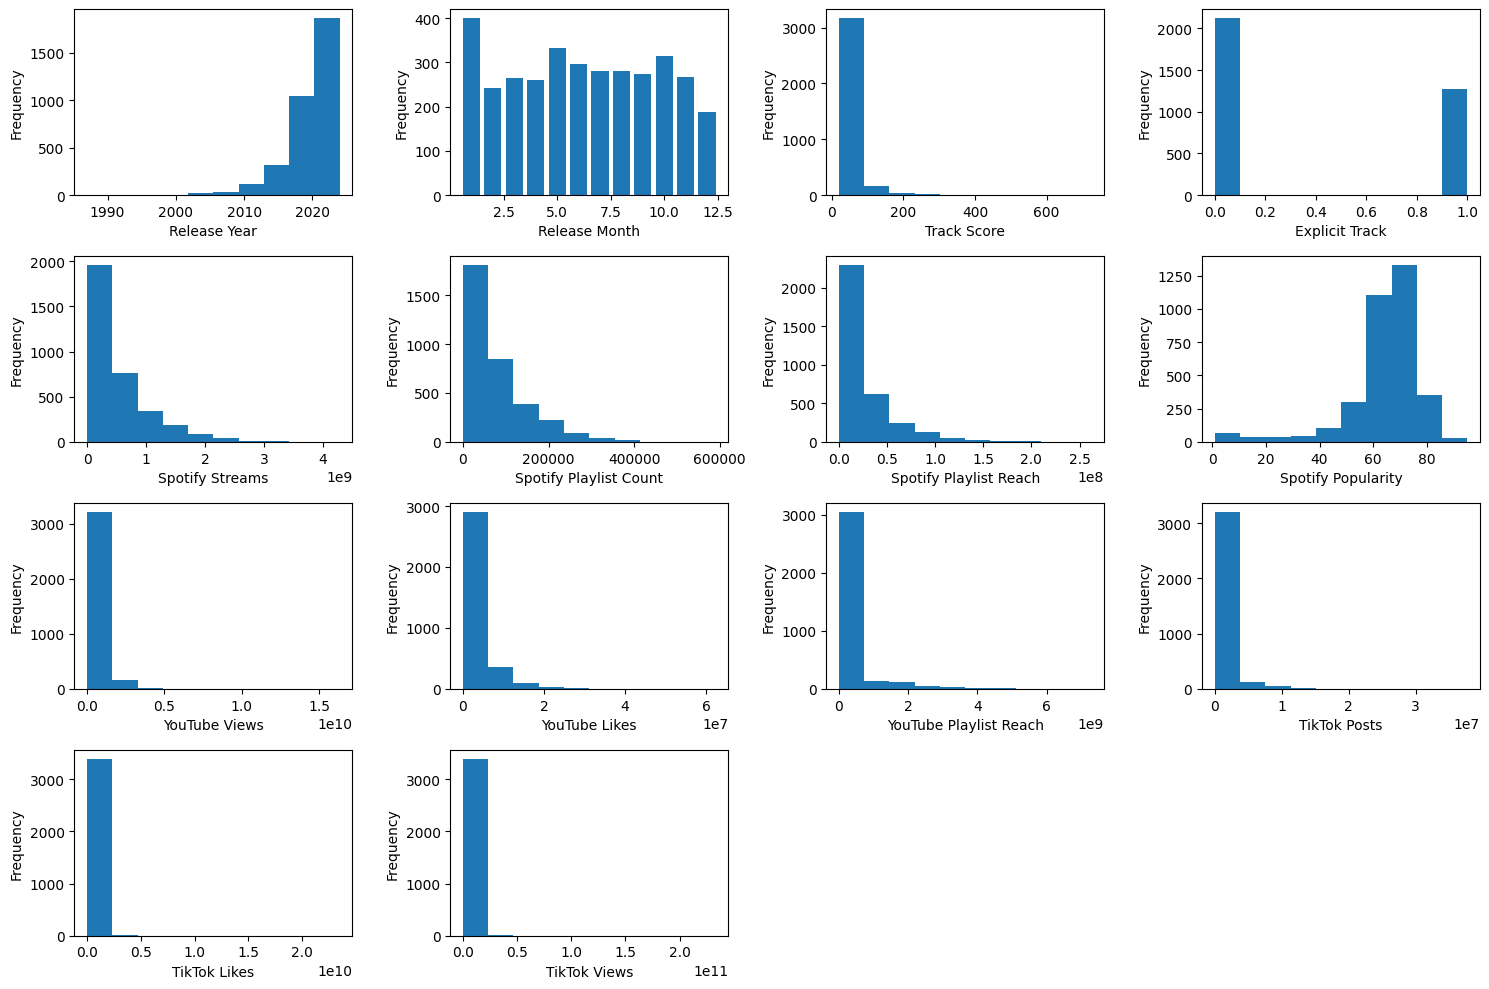

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))

i = 0
for col in DataSet.columns[3:]:
  i=i+1
  plt.subplot(4,4,int(i))
  if col == 'Release Month':
    counts = DataSet['Release Month'].value_counts()
    plt.bar(counts.index, counts.values)
  else:
    plt.hist(DataSet[col])
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In base ai grafici appena plottati, le distribuzioni risultano essere asimmetriche. Pertanto per le variabili numeriche come misura di centralità consideriamo la mediana (per la variabile Release Year consideriamo anche la moda) e come misure di dispersione il Range, Q1, Q3 ed IQR.

Per le variabili categoriche (Explicit Track e Release Month) consideriamo solo la moda.

In [ ]:
for col in DataSet.columns[3:]:
  print(col.upper())
  if col == 'Explicit Track' or col == 'Release Month':
    print('Moda:', DataSet[col].mode()[0])
    print()
  else:
    if col == 'Release Year':
      print('Moda:', DataSet[col].mode()[0])
    print('Mediana:', DataSet[col].median())
    print()
    print('Range:', DataSet[col].max()-DataSet[col].min())
    print('Q1:', DataSet[col].quantile(q=0.25))
    print('Q3:', DataSet[col].quantile(q=0.75))
    print('IQR:', DataSet[col].quantile(q=0.75)-DataSet[col].quantile(q=0.25))
    print()
  print()


RELEASE YEAR
Moda: 2023
Mediana: 2021.0

Range: 37
Q1: 2018.0
Q3: 2023.0
IQR: 5.0


RELEASE MONTH
Moda: 1


TRACK SCORE
Mediana: 30.1

Range: 706.0
Q1: 23.5
Q3: 45.2
IQR: 21.700000000000003


EXPLICIT TRACK
Moda: 0


SPOTIFY STREAMS
Mediana: 344701547.5

Range: 4281467336.0
Q1: 131970573.0
Q3: 721002313.0
IQR: 589031740.0


SPOTIFY PLAYLIST COUNT
Mediana: 54316.500001000044

Range: 590391.0000000002
Q1: 21434.000001
Q3: 108131.75000100004
IQR: 86697.75000000003


SPOTIFY PLAYLIST REACH
Mediana: 16111811.000000987

Range: 262343412.00000027
Q1: 7009169.500001004
Q3: 32817030.250001047
IQR: 25807860.750000045


SPOTIFY POPULARITY
Mediana: 67.00000099999997

Range: 94.00000000000044
Q1: 61.00000099999998
Q3: 72.00000100000003
IQR: 11.000000000000043


YOUTUBE VIEWS
Mediana: 179814248.50000098

Range: 16322745043.00001
Q1: 59895574.25000099
Q3: 525305850.0000005
IQR: 465410275.74999946


YOUTUBE LIKES
Mediana: 1597125.500001001

Range: 62311107.99999995
Q1: 578844.7500010001
Q3: 3998168.50

*Correlazione*

Per iniziare lo studio della correlazione tra le variabili del nostro dataset, visualizziamo la scatter matrix, dove sulla diagonale principale ci sono gli istogrammi di ciascuna variabile mentre nelle restanti entrate sono presenti gli scatter plot.

[]

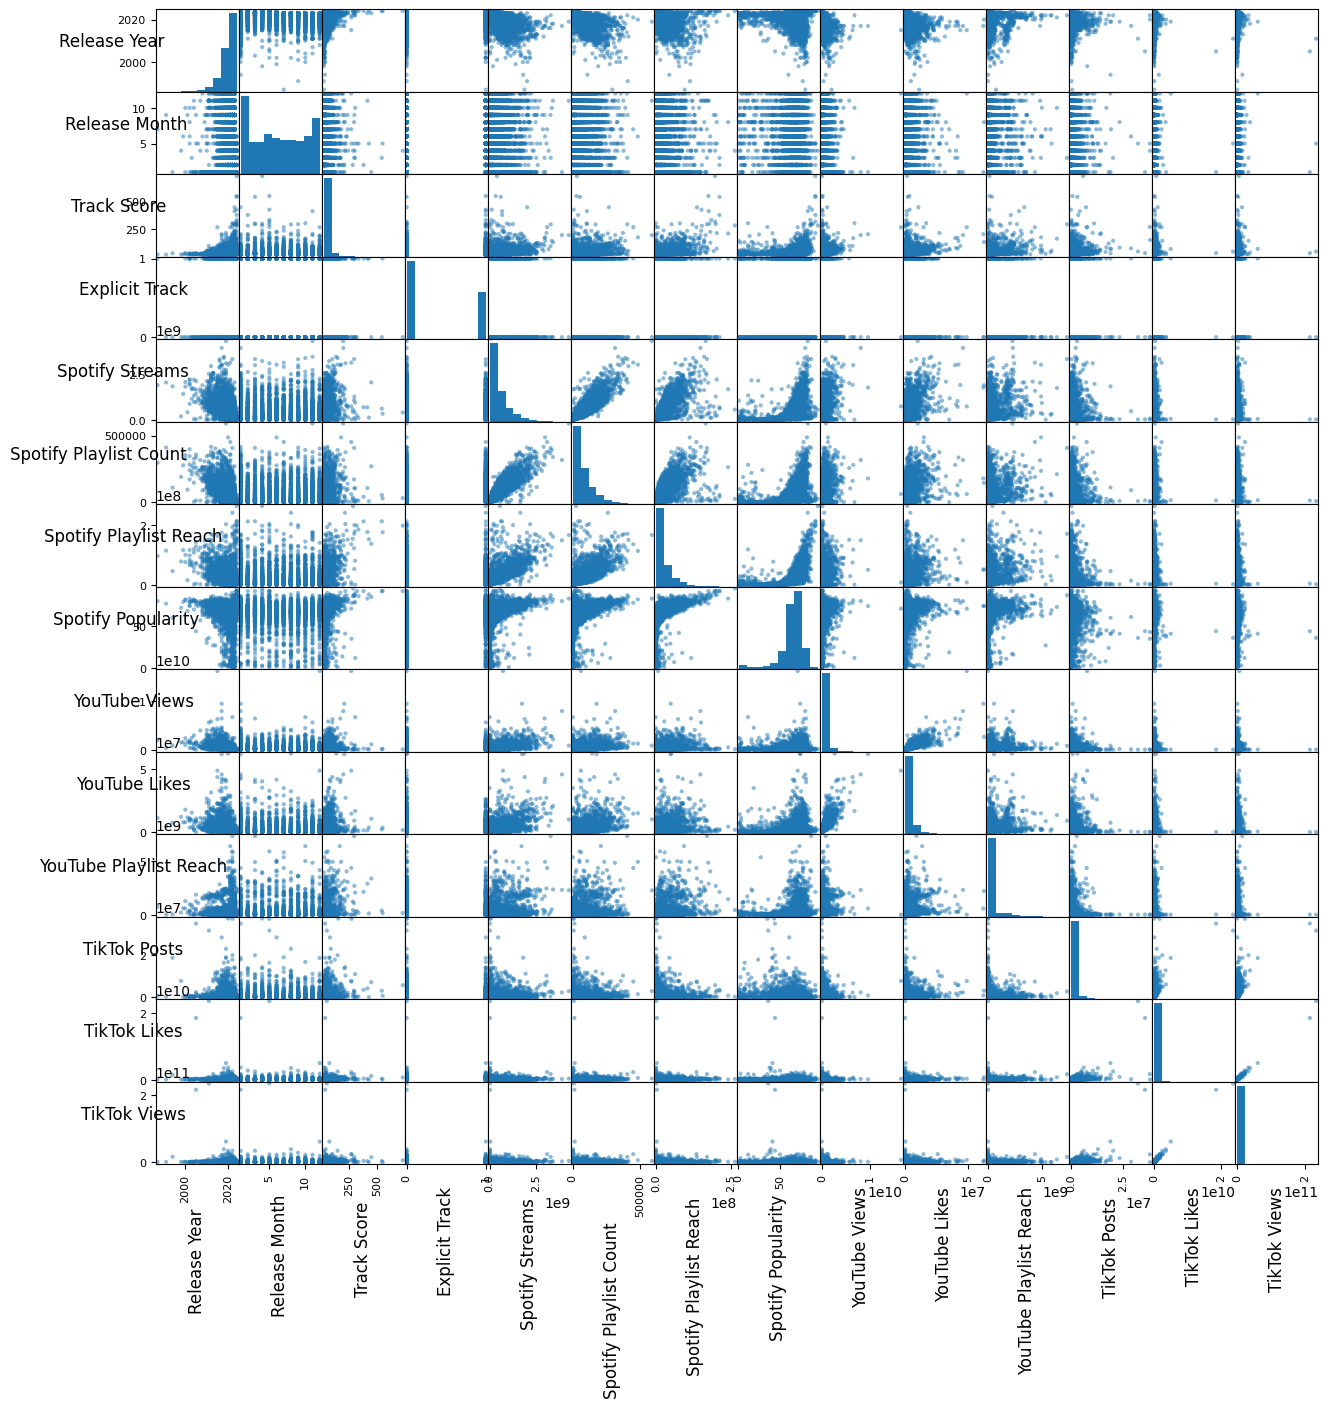

In [ ]:
scatter_matrix = pd.plotting.scatter_matrix(DataSet[['Release Year','Release Month','Track Score','Explicit Track','Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach','Spotify Popularity',
                                    'YouTube Views','YouTube Likes','YouTube Playlist Reach', 'TikTok Posts','TikTok Likes','TikTok Views']],figsize=(15,15))

for ax in scatter_matrix.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize=12, rotation=90)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12, rotation=0)

plt.plot()

Chiaramente i plot che si ottengono con le variabili categoriche (Release Month e Explicit Track) sono difficili da interpretare e non forniscono alcuna informazione rilevante.

Nello studio della correlazione tra le diverse variabili, per prima cosa ci concentriamo su quelle numeriche. Tra le misure di correlazione conosciute, in questo caso, abbiamo deciso di utilizzare quella di Spearman.

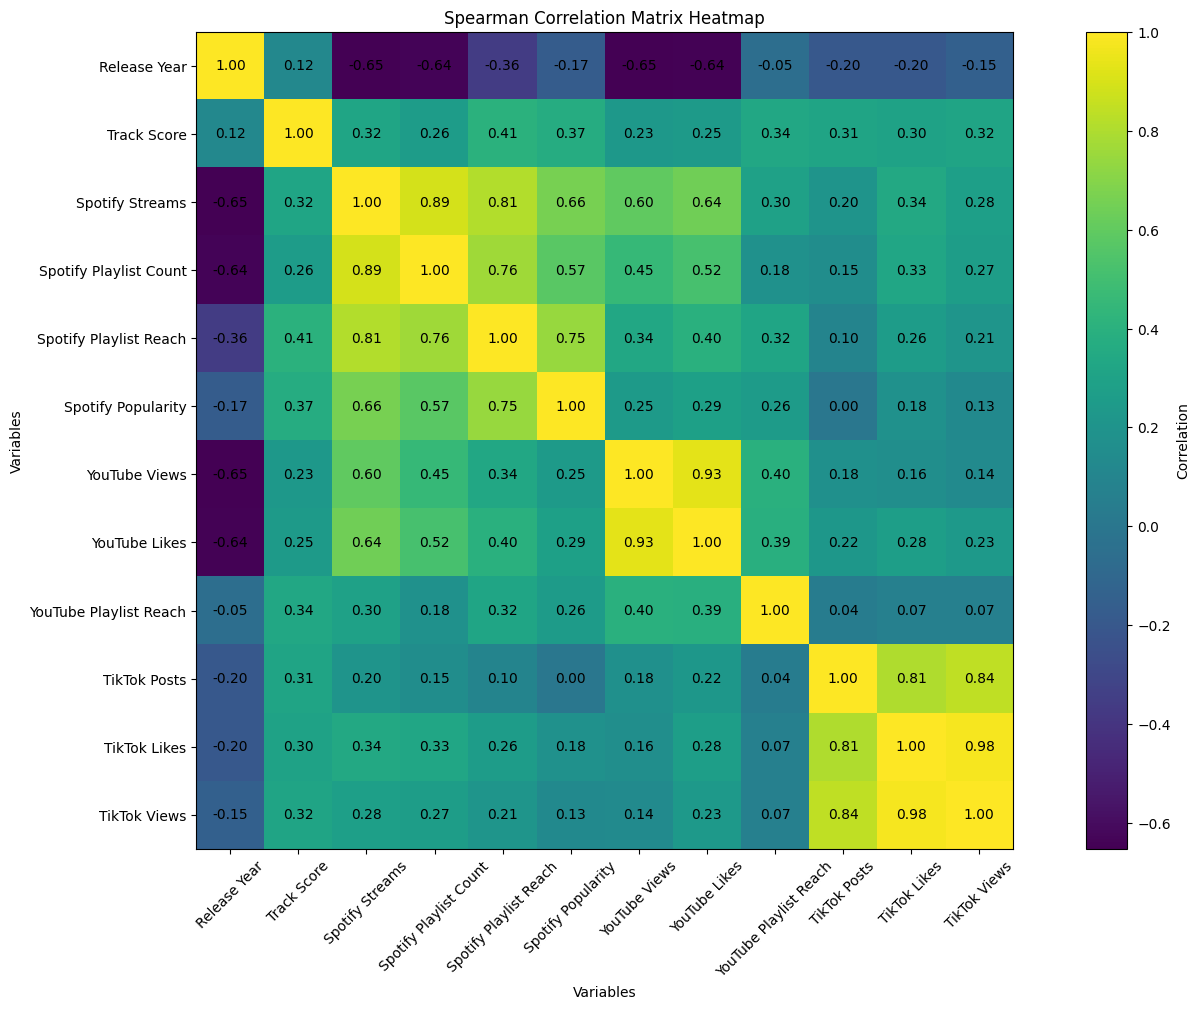

In [ ]:
import numpy as np
corr_spearman=DataSet[['Release Year','Track Score','Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach','Spotify Popularity',
                       'YouTube Views','YouTube Likes','YouTube Playlist Reach','TikTok Posts','TikTok Likes','TikTok Views']].corr(method='spearman')

plt.figure(figsize=(15, 10))
plt.imshow(corr_spearman, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.title('Spearman Correlation Matrix Heatmap')

for i in range(len(corr_spearman)):
    for j in range(len(corr_spearman)):
        plt.text(j, i, f"{corr_spearman.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.xticks(ticks=np.arange(len(corr_spearman.columns)), labels=corr_spearman.columns, rotation=45)
plt.yticks(ticks=np.arange(len(corr_spearman.columns)), labels=corr_spearman.columns)
plt.tight_layout()
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()

La matrice di correlazione, ottenuta tramite l'utilizzo del coefficiente di correlazione di Spearman, ci permette di identificare le relazioni lineari o monotone tra le variabili numeriche. I valori sono compresi tra -1 e 1, dove valori vicini a 1 indicano una forte correlazione positiva, valori vicini a -1 indicano una forte correlazione negativa e valori vicini a 0 indicano che non c'è correlazione.

Ora usiamo il test del chi2 per calcolare la correlazione tra la variabile binaria (Explicit Track) e la variabile categorica (Release Month).

Il test del chi2 è un test statistico utilizzato per determinare se esiste una relazione significativa tra due variabili categoriche.

In [ ]:
from scipy.stats import chi2_contingency
cross_tab = pd.crosstab(DataSet['Release Month'],DataSet['Explicit Track'])
chi2, p, dof, expected = chi2_contingency (cross_tab)
print ("Test del chi-quadrato tra 'Release Month' e 'Explicit Track':")
print ("Valore di chi-quadrato:", chi2)
print ("P-value:", p)
print('gradi di libertà:', dof)

Test del chi-quadrato tra 'Release Month' e 'Explicit Track':
Valore di chi-quadrato: 31.78683069081876
P-value: 0.0008251590799115731
gradi di libertà: 11


Per poter dire se queste due variabili sono correlate o meno, bisogna guardare la tavola dei valori critici del chi2 .
Il valore all'incrocio tra il grado di libertà e il livello di significatività è 31.264 < 31.365. Alla luce di ciò si ottiene che le due variabili sono correlate.

Infine, per confrontare la variabile 'Explicit Track' (binaria) con le colonne numeriche scegliamo di usare il metodo Point-Biserial.

Esso ci restituisce un valore compreso tra -1 e 1:

valori vicini a 1 indicano che c'è una forte associazione tra la presenza della variabile binaria e valori più alti della variabile numerica;

valori vicini a -1 indicano una forte associazione tra la presenza della variabile binaria e valori più bassi della variabile numerica;

valori vicini a 0 indicano che non c'è una forte associazione tra la variabile binaria e la variabile numerica.



In [ ]:
from scipy.stats import chi2_contingency, pointbiserialr
for col in ['Track Score','Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach','Spotify Popularity', 'YouTube Views','YouTube Likes','YouTube Playlist Reach','TikTok Posts','TikTok Likes','TikTok Views']:
    statistic, p_value = pointbiserialr(DataSet[col], DataSet['Explicit Track'])
    if p_value < 0.05:
        print(f'Il risultato del test è significativo. La correlazione tra Explicit Track e {col}: {statistic}')
    else:
        print(f'Non possiamo dire nulla sulla correlazione tra Explicit Track e {col}')

Il risultato del test è significativo. La correlazione tra Explicit Track e Track Score: 0.03866290953396428
Non possiamo dire nulla sulla correlazione tra Explicit Track e Spotify Streams
Il risultato del test è significativo. La correlazione tra Explicit Track e Spotify Playlist Count: 0.11898317715409489
Il risultato del test è significativo. La correlazione tra Explicit Track e Spotify Playlist Reach: -0.034951206980913974
Non possiamo dire nulla sulla correlazione tra Explicit Track e Spotify Popularity
Il risultato del test è significativo. La correlazione tra Explicit Track e YouTube Views: -0.14328592870488085
Il risultato del test è significativo. La correlazione tra Explicit Track e YouTube Likes: -0.11021159576192086
Il risultato del test è significativo. La correlazione tra Explicit Track e YouTube Playlist Reach: -0.07140700406328059
Il risultato del test è significativo. La correlazione tra Explicit Track e TikTok Posts: -0.04891839362733917
Non possiamo dire nulla sulla 

Nel caso di test significativo, dal momento che i coefficienti di Point Biserial sono tutti vicini allo 0, le due variabili considerate non sono correlate.

# **Outlier Detection**

Procediamo col determinare se ci sono o meno outlier con metodi opportuni. Ci concentriamo su tutte le variabili numeriche, escludendo la variabile categorica Release Month.

In [ ]:
columns_outlier = ['Release Year', 'Explicit Track','Track Score','Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity',
                  'YouTube Views', 'YouTube Likes', 'YouTube Playlist Reach', 'TikTok Posts', 'TikTok Likes', 'TikTok Views']
df_outliers=DataSet[columns_outlier]
df_outliers.head()

,Release Year,Explicit Track,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,2024,0,725.4,3.904709e+08,30716.000001,1.966316e+08,92.000001,8.427475e+07,1.713126e+06,1.505970e+08,5.767700e+06,6.515659e+08,5.332282e+09
1,2024,1,545.9,3.237039e+08,28113.000001,1.745971e+08,92.000001,1.163470e+08,3.486739e+06,1.563804e+08,6.747000e+05,3.522355e+07,2.083390e+08
2,2024,0,538.4,6.013093e+08,54331.000001,2.116077e+08,92.000001,1.225991e+08,2.228730e+06,3.737850e+08,3.025400e+06,2.751542e+08,3.369121e+09
3,2023,0,444.9,2.031281e+09,269802.000001,1.365691e+08,85.000001,1.096101e+09,1.062980e+07,3.351189e+09,7.189811e+06,1.078758e+09,1.460373e+10
4,2024,1,423.3,1.070349e+08,7223.000001,1.514699e+08,88.000001,7.737396e+07,3.670188e+06,1.127639e+08,1.640000e+04,1.208962e+07,7.354130e+07


Innanzitutto, determiniamo gli outlier globali tramite il metodo DBSCAN. Tale metodo è un algoritmo di clustering che va a creare attorno ad ogni punto un'ipersfera avente un determinato raggio. Individuando tutte quelle ipersfere che non hanno punti al loro interno, è in grado di determinare gli outlier che si trovano in regioni poco dense dello spazio.

Dato che in DBSCAN viene utilizzato KNN, che è un algoritmo di machine learning, è utile prima plottare le distribuzioni per scegliere l'opportuna trasformazione da effettuare e poi andare a normalizzare.

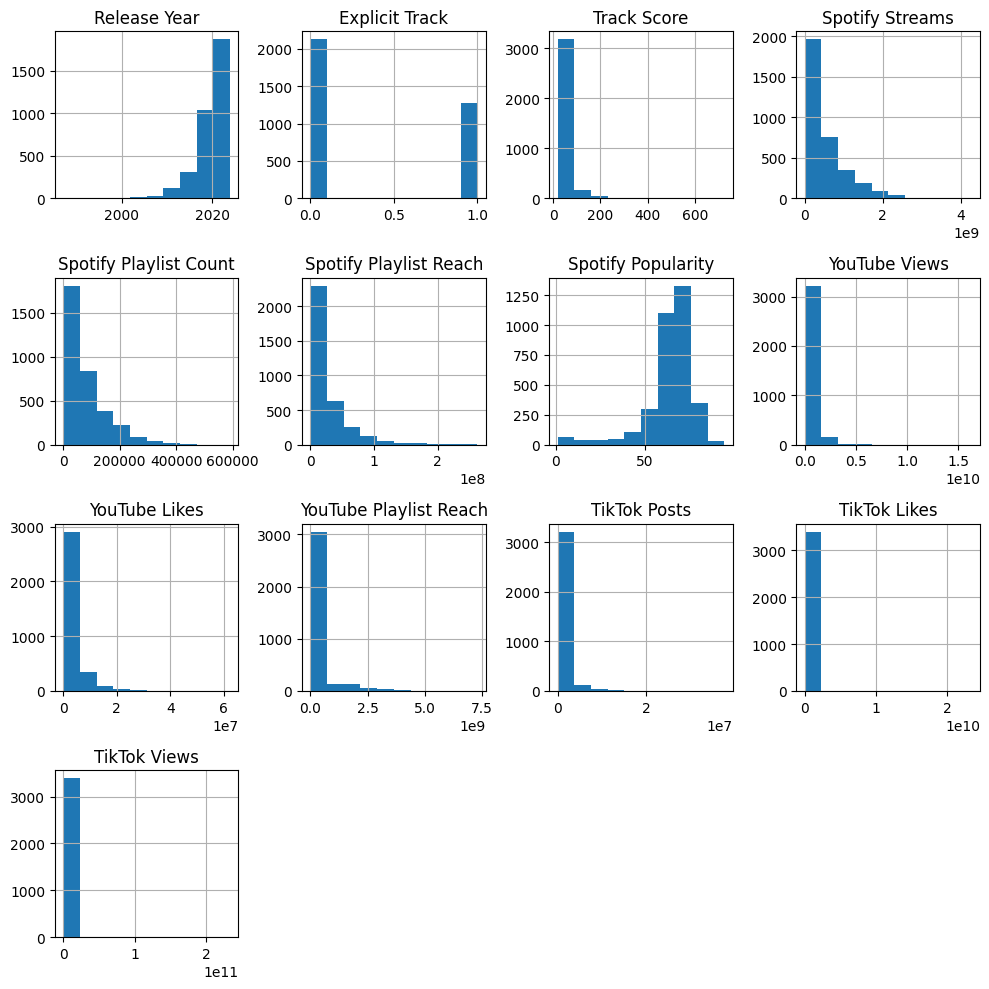

In [ ]:
df_outliers.hist(figsize=[10,10])
plt.tight_layout()
plt.show()

Osservando i plot, decidiamo di non apportare alcuna trasformazione alle variabili Release Year e Explicit Track, di applicare il logaritmo a tutte quelle aventi una coda lunga a destra e di usare la trasformazione Box-Cox per le restanti.

In [ ]:
from scipy.stats import boxcox
no_transf=['Release Year', 'Explicit Track']
to_log=['Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'YouTube Likes', 'YouTube Playlist Reach']
to_box_cox=['Track Score', 'Spotify Popularity', 'YouTube Views', 'TikTok Posts', 'TikTok Likes', 'TikTok Views']

df_transformed=df_outliers.copy()
for var in to_log:
  df_transformed[var]=np.log(df_outliers[var]+ 1e-6)
for var in to_box_cox:
  df_transformed[var],lambda0 = boxcox(df_outliers[var] + 1e-6)

In [ ]:
df_transformed.head()

,Release Year,Explicit Track,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,2024,0,0.883123,19.782864,10.332539,19.096842,37859.289056,114.388284,14.353830,18.830118,42.960700,119.890730,138.989530
1,2024,1,0.882929,19.595340,10.243987,18.977992,37859.289056,120.903148,15.064477,18.867802,31.736615,76.670425,87.841698
2,2024,0,0.882918,20.214620,10.902850,19.170245,37859.289056,121.993269,14.616942,19.739191,39.292627,105.200422,130.346718
3,2023,0,0.882745,21.431932,12.505444,18.732341,30972.088937,177.074836,16.179172,21.932581,44.276699,129.358624,159.901120
4,2024,1,0.882694,18.488666,8.885026,18.835897,33821.337401,112.719133,15.115753,18.540806,17.746515,64.826289,75.555863


Andiamo a normalizzare le distribuzioni con il Robust Scaler.

In [ ]:
scaler=RobustScaler()
columns_to_scale = ['Release Year', 'Explicit Track', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach',
                    'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'YouTube Playlist Reach', 'TikTok Posts', 'TikTok Likes', 'TikTok Views']
df_transformed_scaled=pd.DataFrame(scaler.fit_transform(df_transformed), columns=columns_to_scale)
df_transformed_scaled.head()

,Release Year,Explicit Track,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,0.6,0.0,1.405494,0.073422,-0.352233,1.620608,2.997908,-0.327303,0.036281,0.266934,1.400911,1.510273,1.378378
1,0.6,1.0,1.390529,-0.037013,-0.406949,1.543619,2.997908,-0.192954,0.404004,0.277602,0.467965,0.064637,-0.133031
2,0.6,0.0,1.389671,0.327685,0.000165,1.668157,2.997908,-0.170473,0.172428,0.524299,1.096021,1.018911,1.122984
3,0.4,0.0,1.376358,1.044568,0.990415,1.384491,2.011196,0.965414,0.980802,1.145265,1.510297,1.826956,1.996311
4,0.6,1.0,1.372385,-0.688740,-1.246658,1.451573,2.419401,-0.361724,0.430537,0.185027,-0.694892,-0.331527,-0.496075


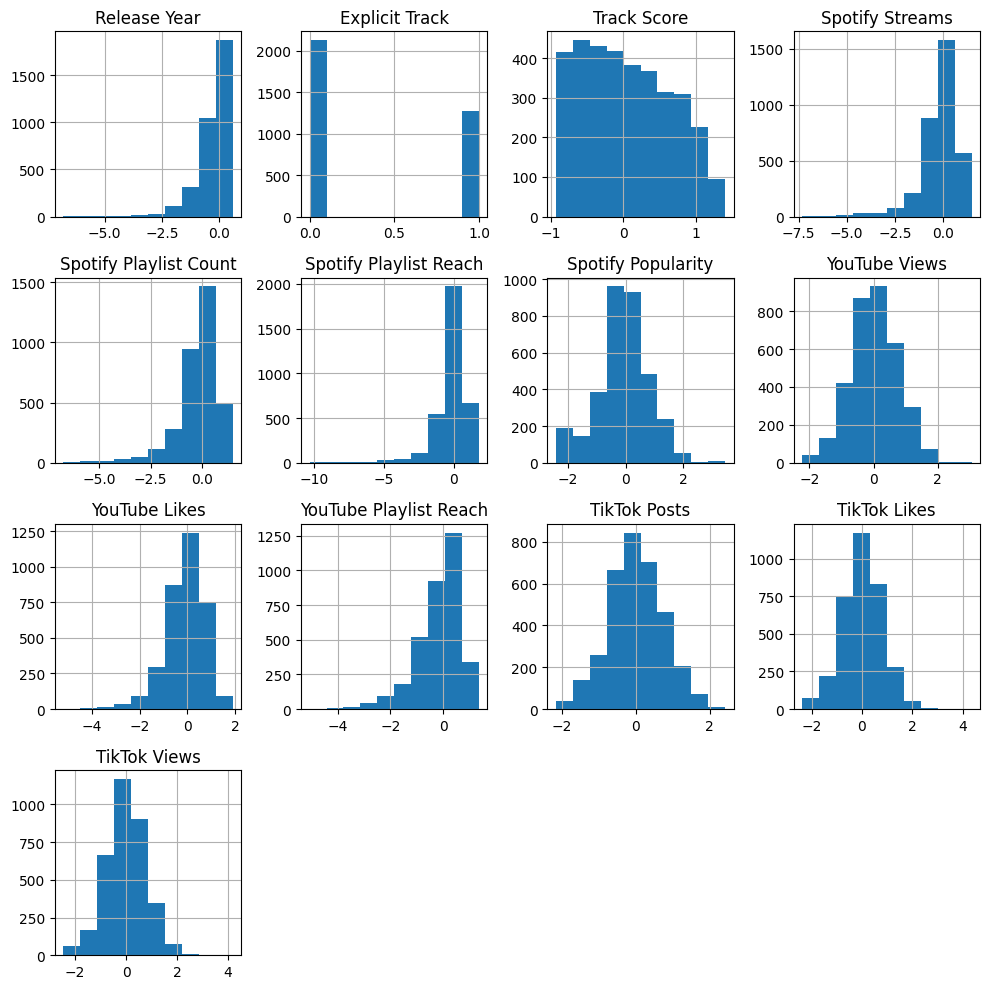

In [ ]:
df_transformed_scaled.hist(figsize=[10,10])
plt.tight_layout()
plt.show()

Applichiamo DBSCAN scegliendo min_samples=15 > numero di colonne + 1

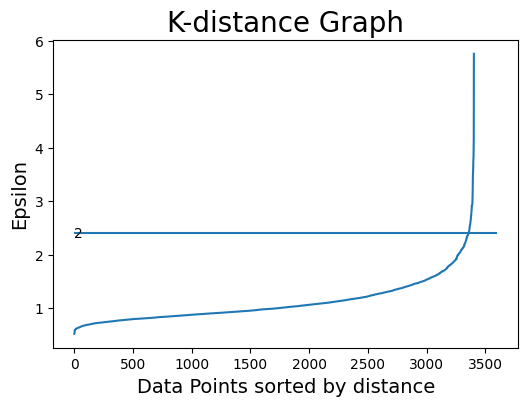

Value Counts:
-1: 69
0: 3335


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(df_transformed_scaled)
distances, indices = nbrs.kneighbors(df_transformed_scaled)

# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,-1]
plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14,color='k')
plt.hlines(2.4, 3600, 0)
plt.text(0, 2.4, '2', ha ='left', va ='center')
plt.show()


model = DBSCAN(eps = 2.4, min_samples = 26).fit(df_transformed_scaled)
labels_dbscan = model.labels_
outliers_DBSCAN=(labels_dbscan==-1).astype(int)


# Get unique values and their counts
unique_values, counts = np.unique(labels_dbscan, return_counts=True)

# Create a dictionary to store the counts of each value
value_counts = dict(zip(unique_values, counts))

# Print the value counts
print("Value Counts:")
for value, count in value_counts.items():
    print(f"{value}: {count}")

Sono stati individuati in tutto 56 outlier globali.

Facciamo lo scatter plot tra la variabile Spotify Streams e alcune altre variabili prese in esame.

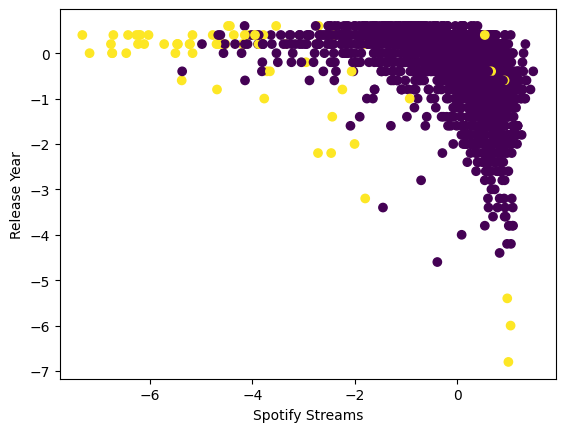

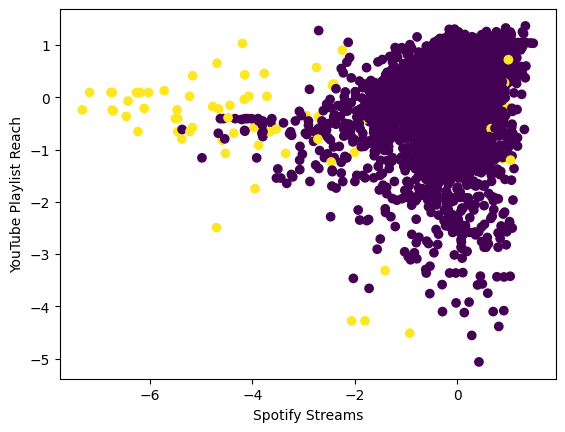

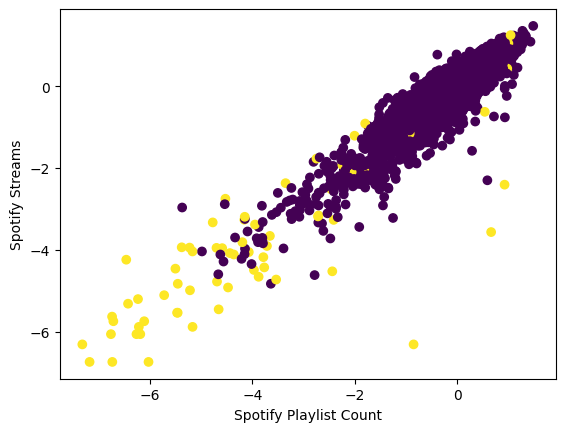

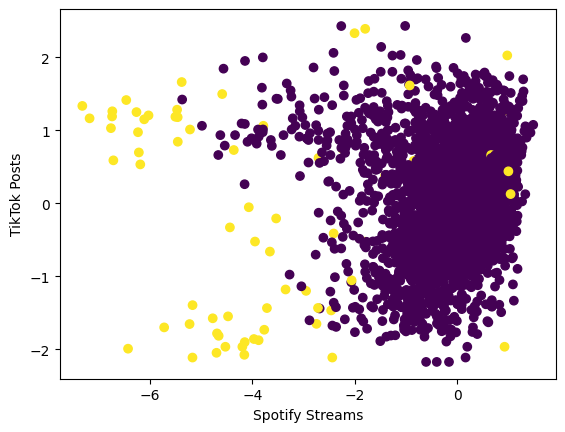

In [ ]:
plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['Release Year'],c=outliers_DBSCAN)
plt.xlabel('Spotify Streams')
plt.ylabel('Release Year')
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['YouTube Playlist Reach'],c=outliers_DBSCAN)
plt.xlabel('Spotify Streams')
plt.ylabel('YouTube Playlist Reach')
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'], df_transformed_scaled['Spotify Playlist Count'],c=outliers_DBSCAN)
plt.xlabel('Spotify Playlist Count')
plt.ylabel('Spotify Streams')
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['TikTok Posts'],c=outliers_DBSCAN)
plt.xlabel('Spotify Streams')
plt.ylabel('TikTok Posts')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)
principal_components = pca.fit_transform(df_transformed)

# Creare un nuovo DataFrame con le tre componenti principali
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

color_map = {0: 'purple', 1: 'gold'}
colors = [color_map[val] for val in outliers_DBSCAN]

fig.add_trace(go.Scatter3d(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    z=df_pca['PC3'],
    mode='markers',
    marker=dict(size=5, color=colors, line=dict(color='black',width=1))
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)


fig.show()

Vediamo se ci sono anche degli outlier locali tramite il metodo LOF. Tale metodo confronta la densità di ciascun punto con quella dei suoi vicini: se un punto ha una densità molto più piccola rispetto a quella dei suoi vicini (e quindi è un punto isolato localmente), viene considerato un outlier.

Anche questo metodo utilizza KNN, quindi ha senso proseguire con i dati trasformati e normalizzati.

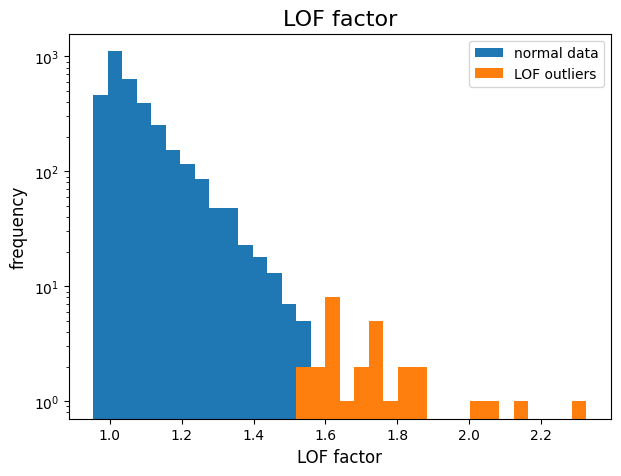

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# fit the model for outlier detection (default)
lof = LocalOutlierFactor(novelty=False,contamination=0.0085)
labels_lof = lof.fit_predict(df_transformed_scaled)


#plot LOF scores
lof_scores=-lof.negative_outlier_factor_
plt.figure(figsize=(7,5))
plt.hist(lof_scores[labels_lof>-1],bins=np.linspace(min(lof_scores), max(lof_scores), 35),label='normal data')
plt.hist(lof_scores[labels_lof==-1],bins=np.linspace(min(lof_scores), max(lof_scores), 35),label='LOF outliers')
plt.xlabel('LOF factor',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title('LOF factor',fontsize=16)
plt.legend()
plt.yscale('log')
plt.show()

Allo stesso modo, facciamo gli scatter plot tra la variabile Spotify Streams e le variabili considerate precedentemente.

Numero di outlier locali: 29



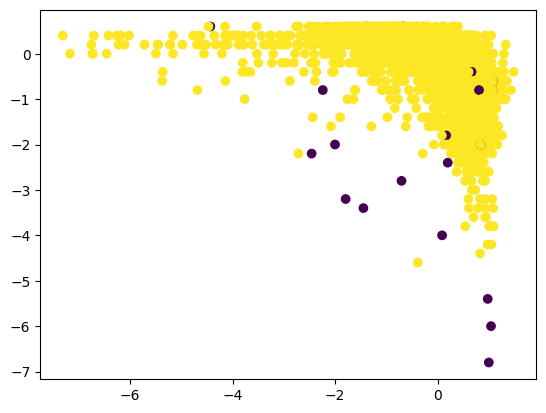

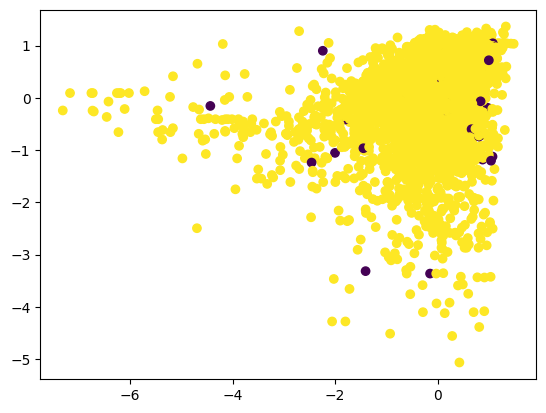

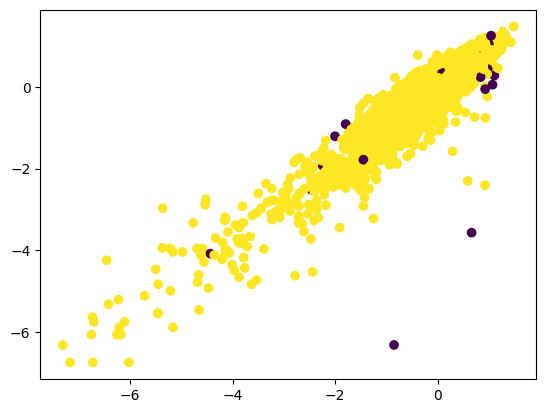

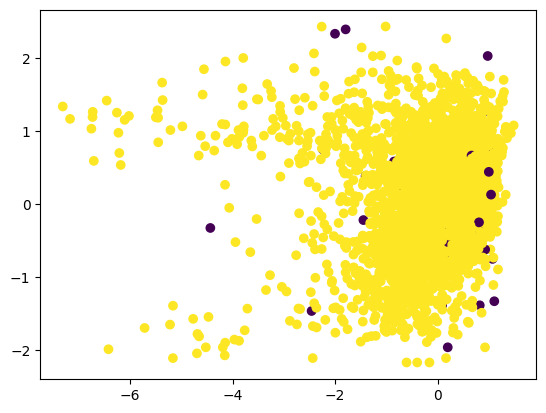

In [ ]:
print('Numero di outlier locali:', (labels_lof==-1).sum())
print()
plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['Release Year'],c=labels_lof)
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['YouTube Playlist Reach'],c=labels_lof)
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['Spotify Playlist Count'],c=labels_lof)
plt.show()

plt.scatter(df_transformed_scaled['Spotify Streams'],df_transformed_scaled['TikTok Posts'],c=labels_lof)
plt.show()



In [ ]:
fig = go.Figure()

color_map = {-1: 'gold', 1: 'purple'}
colors = [color_map[val] for val in labels_lof]

fig.add_trace(go.Scatter3d(
    x=df_pca['PC1'],
    y=df_pca['PC2'],
    z=df_pca['PC3'],
    mode='markers',
    marker=dict(size=5, color=colors, line=dict(color='black',width=1))
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)


fig.show()

In tutto abbiamo 30 outlier locali.

Verifichiamo quanti di questi sono anche globali.

In [ ]:
print("Numero di outliers coincidenti:", np.sum(labels_lof == labels_dbscan))

Numero di outliers coincidenti: 10


In tutto abbiamo 71 outlier.

Dagli scatter plot osserviamo che è possibile identificare insiemi di outlier globali sparsi che si discostano maggiormente dalla distribuzione degli altri punti. Nonostante gli altri outlier individuati non siano molto distanti dagli altri punti, decidiamo comunque di rimuoverli tutti. Facendo così è possibile rimuovere del rumore che potrebbe causare problemi in fase di predizione.

La maggiorparte degli outlier individuati da LOF non si discosta significativamente dalla distribuzione degli altri punti. Gli unici outlier locali che risultano punti anomali vengono identificati anche da DBSCAN. Dunque, decidiamo di non eliminare questa tipologia di outlier.



In [ ]:
df_no_outlier=DataSet.copy()
df_no_outlier=df_no_outlier[(labels_dbscan!=-1)]
df_no_outlier

,Track,Album Name,Artist,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024,4,725.4,0,3.904709e+08,30716.000001,1.966316e+08,92.000001,8.427475e+07,1.713126e+06,1.505970e+08,5.767700e+06,6.515659e+08,5.332282e+09
1,Not Like Us,Not Like Us,Kendrick Lamar,2024,5,545.9,1,3.237039e+08,28113.000001,1.745971e+08,92.000001,1.163470e+08,3.486739e+06,1.563804e+08,6.747000e+05,3.522355e+07,2.083390e+08
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024,3,538.4,0,6.013093e+08,54331.000001,2.116077e+08,92.000001,1.225991e+08,2.228730e+06,3.737850e+08,3.025400e+06,2.751542e+08,3.369121e+09
3,Flowers,Flowers - Single,Miley Cyrus,2023,1,444.9,0,2.031281e+09,269802.000001,1.365691e+08,85.000001,1.096101e+09,1.062980e+07,3.351189e+09,7.189811e+06,1.078758e+09,1.460373e+10
4,Houdini,Houdini,Eminem,2024,5,423.3,1,1.070349e+08,7223.000001,1.514699e+08,88.000001,7.737396e+07,3.670188e+06,1.127639e+08,1.640000e+04,1.208962e+07,7.354130e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,3 Haselnï¿½ï¿,3 Haselnï¿½ï¿½sse - Si,Jaques Raupï¿,2023,12,19.4,0,2.582218e+07,15387.000001,2.650670e+06,58.281943,7.041124e+06,1.279980e+05,4.831155e+07,4.034000e+03,1.858466e+06,3.106192e+07
3400,For the Last Time,For the Last Time,$uicideboy$,2017,9,19.4,1,3.050500e+08,65770.000001,5.103054e+06,71.000001,1.492477e+08,1.397590e+06,5.301600e+04,4.837000e+04,2.020200e+07,1.439344e+08
3401,Grace (feat. 42 Dugg),My Turn,Lil Baby,2020,2,19.4,1,1.899727e+08,72066.000001,6.704802e+06,65.000001,2.010273e+08,1.081402e+06,2.925315e+07,7.596000e+03,5.288677e+06,3.684901e+07
3402,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,2016,11,19.4,0,1.454670e+08,14037.000001,7.387064e+06,66.000001,1.118595e+09,3.868828e+06,2.515052e+07,1.143300e+04,2.534831e+06,3.775730e+07


# **Predizione**

Vogliamo predire il numero di streams su Spotify a partire dalle altre informazioni che abbiamo su ciascuna canzone, utilizzando un modello di regressione lineare.

In [ ]:
df_pred=df_no_outlier.copy()
df_pred.drop(['Track', 'Album Name', 'Artist'], axis=1, inplace=True)
df_pred.head()

,Release Year,Release Month,Track Score,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,YouTube Playlist Reach,TikTok Posts,TikTok Likes,TikTok Views
0,2024,4,725.4,0,3.904709e+08,30716.0,196631588.0,92.0,8.427475e+07,1713126.0,1.505970e+08,5767700.0,6.515659e+08,5.332282e+09
1,2024,5,545.9,1,3.237039e+08,28113.0,174597137.0,92.0,1.163470e+08,3486739.0,1.563804e+08,674700.0,3.522355e+07,2.083390e+08
2,2024,3,538.4,0,6.013093e+08,54331.0,211607669.0,92.0,1.225991e+08,2228730.0,3.737850e+08,3025400.0,2.751542e+08,3.369121e+09
3,2023,1,444.9,0,2.031281e+09,269802.0,136569078.0,85.0,1.096101e+09,10629796.0,3.351189e+09,7189811.0,1.078758e+09,1.460373e+10
4,2024,5,423.3,1,1.070349e+08,7223.0,151469874.0,88.0,7.737396e+07,3670188.0,1.127639e+08,16400.0,2.568463e+07,1.996146e+08


Innanzitutto, ci concentriamo sulle variabili numeriche che hanno una correlazione moderata (con modulo > 0.35). Dunque, escludiamo le variabili: Track Score, YouTube Playlist Reach, TikTok Posts, TikTok Likes e TikTok Views. Per evitare collinearità (variabili indipendenti fortemente correlate), decidiamo di scartare YouTube Views.

Verifichiamo che le variabili scelte siano adatte al nostro scopo plottando gli scatter plot tra Spotify Streams e le altre variabili, dopo averle opportunamente trasformate.

In [ ]:
df_pred.drop(['Track Score','YouTube Playlist Reach','YouTube Views', 'TikTok Posts', 'TikTok Views','TikTok Likes'], axis=1, inplace=True)
df_pred.head()

,Release Year,Release Month,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Likes
0,2024,4,0,3.904709e+08,30716.0,196631588.0,92.0,1713126.0
1,2024,5,1,3.237039e+08,28113.0,174597137.0,92.0,3486739.0
2,2024,3,0,6.013093e+08,54331.0,211607669.0,92.0,2228730.0
3,2023,1,0,2.031281e+09,269802.0,136569078.0,85.0,10629796.0
4,2024,5,1,1.070349e+08,7223.0,151469874.0,88.0,3670188.0


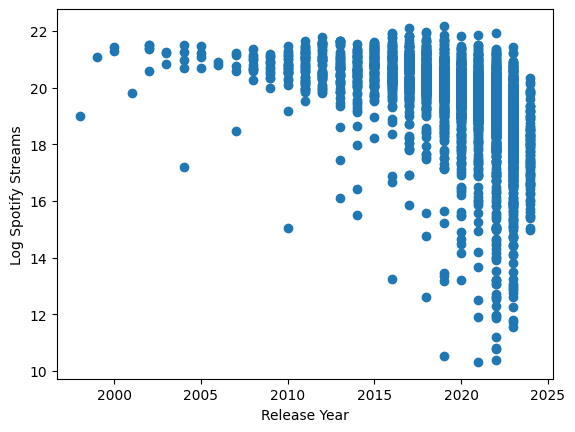

In [ ]:
plt.scatter(df_pred['Release Year'], np.log(df_pred['Spotify Streams']))
plt.xlabel('Release Year')
plt.ylabel('Log Spotify Streams')
plt.show()

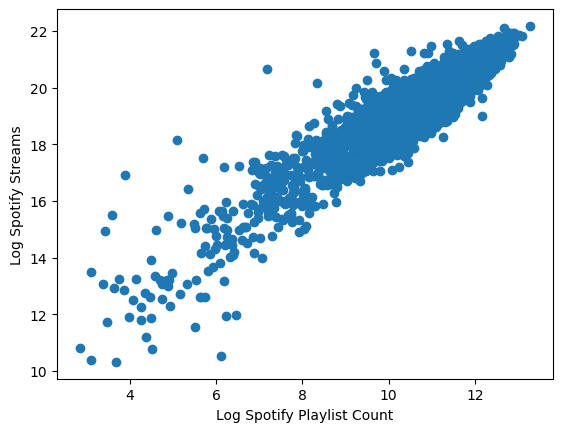

In [ ]:
plt.scatter(np.log(df_pred['Spotify Playlist Count']), np.log(df_pred['Spotify Streams']))
plt.xlabel('Log Spotify Playlist Count')
plt.ylabel('Log Spotify Streams')
plt.show()

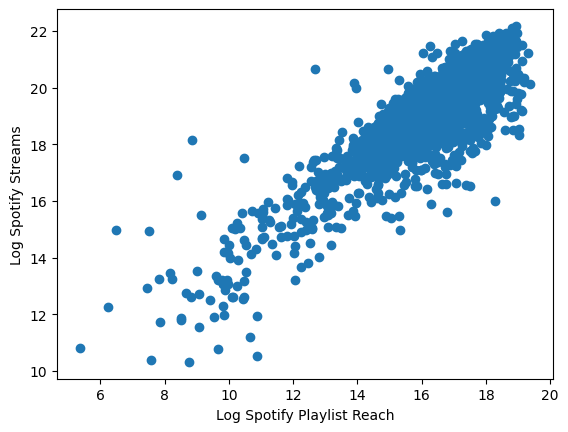

In [ ]:
plt.scatter(np.log(df_pred['Spotify Playlist Reach']), np.log(df_pred['Spotify Streams']))
plt.xlabel('Log Spotify Playlist Reach')
plt.ylabel('Log Spotify Streams')
plt.show()

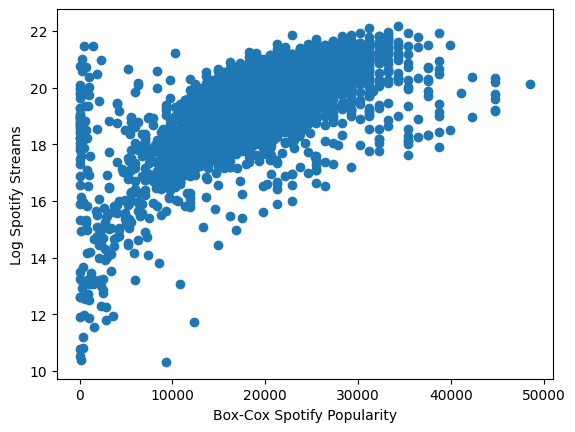

In [ ]:
df_pred['Box-Cox Spotify Popularity'], lambda0 = boxcox(df_pred['Spotify Popularity'] + 1e-6)
plt.scatter(df_pred['Box-Cox Spotify Popularity'], np.log(df_pred['Spotify Streams']))
plt.xlabel('Box-Cox Spotify Popularity')
plt.ylabel('Log Spotify Streams')
plt.show()
df_pred.drop('Box-Cox Spotify Popularity', axis=1, inplace=True)


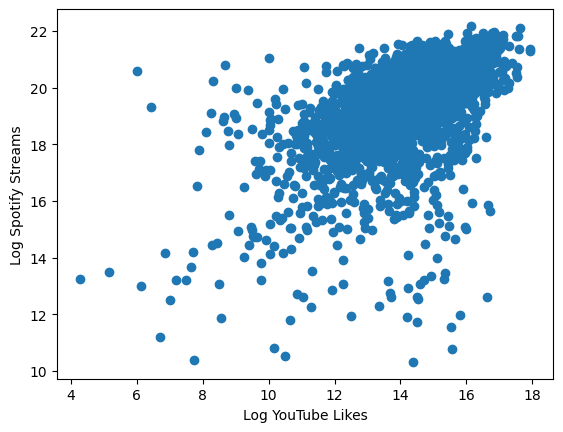

In [ ]:
plt.scatter(np.log(df_pred['YouTube Likes']), np.log(df_pred['Spotify Streams']))
plt.xlabel('Log YouTube Likes')
plt.ylabel('Log Spotify Streams')
plt.show()

Questi scatter plot ci confermano che possiamo continuare col nostro modello di regressione lineare.

Consideriamo ora la correlazione tra le variabili categoriche (Explicit Track e Release Month) con la variabile target (Spotify Streams).


Per gestire opportunamente la variabile categorica Release Month facciamo dummyfication.
Per ogni valore che può assumere la variabile categorica creiamo una nuova colonna che assuma valore 1 se l'osservazione appartiene a quella categoria, 0 altrimenti.

In [ ]:
df_pred_dummy=pd.get_dummies(df_pred,columns=['Release Month'],drop_first=True,dtype=int)
df_pred_dummy.head()

,Release Year,Explicit Track,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Likes,Release Month_2,Release Month_3,Release Month_4,Release Month_5,Release Month_6,Release Month_7,Release Month_8,Release Month_9,Release Month_10,Release Month_11,Release Month_12
0,2024,0,3.904709e+08,30716.0,196631588.0,92.0,1713126.0,0,0,1,0,0,0,0,0,0,0,0
1,2024,1,3.237039e+08,28113.0,174597137.0,92.0,3486739.0,0,0,0,1,0,0,0,0,0,0,0
2,2024,0,6.013093e+08,54331.0,211607669.0,92.0,2228730.0,0,1,0,0,0,0,0,0,0,0,0
3,2023,0,2.031281e+09,269802.0,136569078.0,85.0,10629796.0,0,0,0,0,0,0,0,0,0,0,0
4,2024,1,1.070349e+08,7223.0,151469874.0,88.0,3670188.0,0,0,0,1,0,0,0,0,0,0,0


Ora è possibile analizzare la correlazione (usando Point Biserial) tra le variabili binarie (Explicit Track e quelle appena trasformate attraverso dummyfication) e la variabile numerica (Spotify Streams).

In [ ]:
binary_vars=['Explicit Track', 'Release Month_2', 'Release Month_3', 'Release Month_4', 'Release Month_5', 'Release Month_6',
             'Release Month_7', 'Release Month_8', 'Release Month_9', 'Release Month_10', 'Release Month_11', 'Release Month_12']

from scipy.stats import pointbiserialr
threshold=0.3
binary_for_regressions=[]

for attribute in binary_vars:
  r,p_value=pointbiserialr(df_pred_dummy['Spotify Streams'], df_pred_dummy[attribute])
  if p_value<0.05:
    print(f'Il risultato del test è significativo. La correlazione tra Spotify Streams e {attribute}: {r}')
    if np.abs(r)>0.3:
      binary_for_regressions.append(attribute)
  else:
    print(f'Non possiamo dire nulla sulla correlazione tra Spotify Streams e {attribute}')

Non possiamo dire nulla sulla correlazione tra Spotify Streams e Explicit Track
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_2
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_3
Il risultato del test è significativo. La correlazione tra Spotify Streams e Release Month_4: -0.03503224378739219
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_5
Il risultato del test è significativo. La correlazione tra Spotify Streams e Release Month_6: -0.0495289170466193
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_7
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_8
Il risultato del test è significativo. La correlazione tra Spotify Streams e Release Month_9: -0.043128229735984985
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_10
Non possiamo dire nulla sulla correlazione tra Spotify Streams e Release Month_11
Non po

Dal momento che molti test non risultano essere significativi o comunque la correlazione ottenuta risulta essere molto bassa, non teniamo alcuna variabile binaria.

In [ ]:
binary_for_regressions

[]

Definiamo ora le variabili features e target e dividiamo il dataset in train set e test set. Una volta definite le variabili, le trasformiamo opportunamente e le normalizziamo attraverso Robust Scaler.

Siccome Box-Cox dipende dal parametro lambda, la trasformazione viene calcolata solo sul train set e il lambda ottimale ottenuto viene utilizzato per effettuare sul test set la stessa trasformazione applicata al train set. La stessa cosa viene fatta per il Robust Scaler.

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox

target='Spotify Streams'
no_transf=['Release Year']
to_log=['Spotify Streams','Spotify Playlist Count','Spotify Playlist Reach', 'YouTube Likes']
to_box_cox=['Spotify Popularity']
features=  no_transf + to_log + to_box_cox
features.remove(target)


data_for_reg=df_pred[features+[target]]


data_train, data_test = train_test_split(data_for_reg, test_size=0.3, random_state=0)

for var in to_log:
  data_train[var]=np.log(data_train[var])
  data_test[var]=np.log(data_test[var])

for var in to_box_cox:
  data_train[var], lambda0 = boxcox(data_train[var] + 1e-6)
  data_test[var] = boxcox(data_test[var] + 1e-6, lmbda=lambda0)


scaler = RobustScaler()
to_rescale = features.copy()

transformed_data_train=data_train.copy()
transformed_data_train[to_rescale] = scaler.fit_transform(data_train[to_rescale])

transformed_data_test=data_test.copy()
transformed_data_test[to_rescale] = scaler.transform(data_test[to_rescale])


X_train=transformed_data_train[features]
y_train=transformed_data_train[target]

X_test=transformed_data_test[features]
y_test=transformed_data_test[target]

Infine, prediciamo gli Streams su Spotify usando il modello di regressione lineare.

In [ ]:
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression


lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

MAE=mean_absolute_error(y_test,y_pred)
print(f"L'errore assoluto medio (MAE) della regressione è {MAE}.")
print(f'Il coefficiente R2 della regressione è {r2_score(y_test,y_pred)}.')

mean_actual = np.mean(y_test)

relative_mae = MAE / mean_actual

print(f"L'errore assoluto medio relativo della regressione è {round(relative_mae*100,2)}%")

L'errore assoluto medio (MAE) della regressione è 0.32195215280003114.
Il coefficiente R2 della regressione è 0.903004137965848.
L'errore assoluto medio relativo della regressione è 1.66%


In realtà, ciò che abbiamo predetto è il logaritmo degli Spotify Streams. Per vedere come si comporta il modello sui dati originali senza trasformazione è necessario invertire la trasformazione logaritmo applicando l'esponenziale.

In [ ]:
predicted_df=transformed_data_test[to_rescale].copy()
predicted_df['Log Spotify Streams'] = y_pred
predicted_df[to_rescale]=scaler.inverse_transform(predicted_df[to_rescale])
predicted_df['Spotify Streams']=np.exp(predicted_df['Log Spotify Streams'])

relative_MAE=mean_absolute_error(predicted_df['Spotify Streams'],np.exp(data_test['Spotify Streams']))/np.mean(np.exp(data_test['Spotify Streams']))

print(f"L'errore assoluto medio relativo è: {round(relative_MAE*100,2)}%")

L'errore assoluto medio relativo è: 24.63%


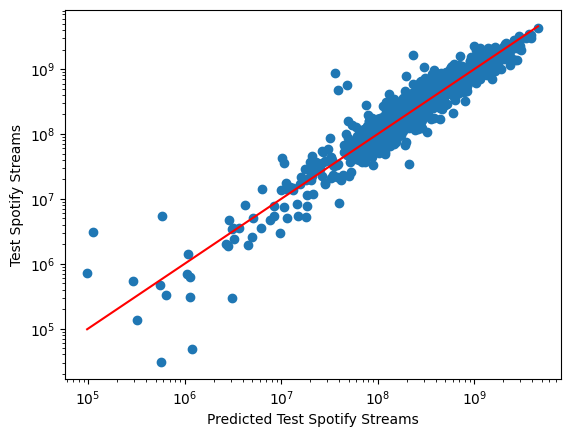

In [ ]:
plt.scatter(predicted_df['Spotify Streams'],np.exp(data_test['Spotify Streams']))
plt.ylabel('Test Spotify Streams')
plt.xlabel('Predicted Test Spotify Streams')
plt.xscale('log')
plt.yscale('log')
x = predicted_df['Spotify Streams']
plt.plot(np.linspace(min(x), max(x), 30), np.linspace(min(x), max(x), 30), color='red')
plt.show()

# **Conclusione**

L'obiettivo di questo progetto era quello di predire gli stream di una canzone sulla piattaforma digitale Spotify a partire da altre informazioni relative alla stessa canzone contenute nel dataset.

Abbiamo innanzitutto pulito il dataset elimando i duplicati e gestendo i NaN. Sono state rimosse tutte quelle righe aventi dati mancanti in corrispondenza della colonna TikTok Posts, invece gli altri NaN sono stati imputati tramite KNN.

Abbiamo ottenuto, così, un dataset adatto a proseguire nell'analisi. Innanzitutto, siamo partiti con un'analisi esplorativa dei dati calcolando le varie misure di centralità e di dispersione e misurando la correlazione tra le diverse variabili del dataset.

Successivamente, abbiamo individuato tutti quei punti anomali (outlier) che si discostassero significativamente dagli altri, al fine di togliere dati rumorosi dal dataset per cercare di costruire un modello predittivo affidabile.

Infine, abbiamo costruito un modello di regressione lineare, trasformando opportunamente le variabili, per predire il logaritmo degli Spotify Streams. In particolare, abbiamo ottenuto un coefficiente $R^2$ di 0.90 e un MAE relativo dell'1.66%. Tuttavia, invertendo il logaritmo, il modello costruito perde un po' in capacità predittiva in quanto si ottiene un MAE relativo del 24.63%.